# Forecasting the Conversion Rates of Digital Advertising with the Help of Machine Learning

## Practical Implementation

This practical work aims to predict digital advertising campaign conversion rates using machine learning techniques. The analysis uses the Digital Advertising Campaign Performance Dataset obtained from Kaggle.

The practical implementation is designed to address all research objectives by performing data preprocessing, exploratory data analysis, feature engineering, model development, model evaluation, and interpretation of key factors influencing conversion rate.

### Import required libraries


In [1]:
# Importing essential libraries for data handling and numerical computation

import os
import numpy as np
import pandas as pd

# Importing visualization libraries for exploratory data analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Importing tools for data splitting, model validation, and hyperparameter tuning

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Importing preprocessing techniques for encoding, scaling, and feature transformation

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Importing regression algorithms for predictive modeling

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Importing evaluation metrics to assess model performance

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppressing unnecessary warning messages for cleaner output display

import warnings
warnings.filterwarnings("ignore")

## Dataset Download

The dataset used in this study is secondary data obtained from Kaggle.
The dataset contains information related to digital advertising campaigns,
including campaign characteristics, audience targeting variables,
engagement metrics, and campaign performance indicators.

However, limited information was available regarding the original data
collection methodology, ownership, and validation procedures of the dataset.
Therefore, it could not be fully verified whether the dataset represents
real-world campaign records or synthetically generated observations.

This limitation is acknowledged as an important consideration affecting
the external validity and generalisability of the study. Despite this,
the dataset remains suitable for comparative machine learning experimentation
and methodological evaluation.

The dependent variable for this study is `conversion_rate`.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juniornsa/digital-advertising-campaign-performance-dataset")

print("Path to dataset files:", path)

100%|██████████| 703k/703k [00:00<00:00, 32.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/juniornsa/digital-advertising-campaign-performance-dataset/versions/1


In [3]:
# Check files in downloaded folder
os.listdir(path)

['tech_advertising_campaigns_dataset.csv']

In [4]:
# Check files in downloaded folder
os.listdir(path)

['tech_advertising_campaigns_dataset.csv']

In [5]:
# Load CSV file automatically

csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
csv_files

['tech_advertising_campaigns_dataset.csv']

In [6]:
df = pd.read_csv(os.path.join(path, csv_files[0]))

df.head()

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,70,2.00,E-commerce,High,0.606,2.23,0.498,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,105,2.74,Finance,Medium,0.932,2.48,1.071,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,149,3.97,Healthcare,Low,1.033,3.88,5.357,72.43,6.68,2468.70
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,...,147,2.49,Education,Medium,1.573,8.29,2.439,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,...,81,3.04,SaaS,Low,1.409,1.41,0.000,0.00,0.00,-425.82


## Initial Data Inspection

The purpose of this section is to understand the structure of the dataset, including the number of observations, number of variables, data types, missing values, and general quality of the data.

This step supports the preprocessing stage of the methodology.

In [7]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 41


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   campaign_id                   10000 non-null  object 
 1   campaign_objective            10000 non-null  object 
 2   platform                      10000 non-null  object 
 3   ad_placement                  10000 non-null  object 
 4   device_type                   10000 non-null  object 
 5   operating_system              10000 non-null  object 
 6   creative_format               10000 non-null  object 
 7   creative_size                 10000 non-null  object 
 8   ad_copy_length                10000 non-null  object 
 9   has_call_to_action            10000 non-null  bool   
 10  creative_emotion              10000 non-null  object 
 11  creative_age_days             10000 non-null  int64  
 12  target_audience_age           10000 non-null  object 
 13  ta

In [9]:
# Summary statistics
df.describe()

,creative_age_days,quarter,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,CTR,CPC,conversion_rate,CPA,ROAS,profit
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,45.3743,2.419100,11.482500,45.429700,5.527400,3.290336,70539.223000,1526.436100,65.568800,4345.566179,2.841577e+04,52.528500,100.956600,3.113223,2.314340,3.290336,3.644033,190.895894,7.524918,2.407020e+04
std,26.1711,1.132424,6.932308,26.071107,1.553541,2.453852,91339.733246,2412.164582,183.404876,6917.481037,8.928461e+04,17.706165,46.541295,1.369884,1.573316,2.453852,4.354338,295.614462,14.985237,8.641610e+04
min,1.0000,1.000000,0.000000,1.000000,1.000000,0.300000,5000.000000,10.000000,0.000000,8.690000,0.000000e+00,10.000000,10.000000,1.000000,0.100000,0.300000,0.000000,0.000000,0.000000,-3.693984e+04
25%,22.0000,1.000000,5.000000,23.000000,4.000000,1.510000,16958.500000,290.000000,5.000000,666.307500,1.608910e+03,40.087500,68.000000,2.160000,1.172000,1.510000,1.005000,40.640000,1.197500,2.094800e+02
50%,45.0000,2.000000,12.000000,45.000000,6.000000,2.430000,37469.500000,718.000000,16.000000,1895.670000,6.099240e+03,53.580000,100.000000,2.830000,1.920000,2.430000,2.165500,99.460000,3.150000,3.302535e+03
75%,68.0000,3.000000,18.000000,68.000000,7.000000,4.530000,83213.750000,1746.000000,55.000000,4996.160000,2.216582e+04,65.472500,132.000000,3.740000,3.017250,4.530000,4.493250,225.457500,7.950000,1.664188e+04
max,90.0000,4.000000,23.000000,90.000000,10.000000,16.030000,500000.000000,40000.000000,5384.000000,49999.680000,2.800397e+06,90.000000,277.000000,8.510000,8.000000,16.030000,25.000000,6379.940000,487.300000,2.750398e+06


In [10]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0


In [11]:
# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Data Cleaning and Preprocessing

Data preprocessing is necessary to prepare the dataset for machine learning. This includes removing unnecessary variables, handling missing values, converting date variables, and separating categorical and numerical features.

The column `campaign_id` is removed because it is only an identifier and does not provide meaningful predictive value.

In [12]:
# Make a copy of original data
data = df.copy()

# Remove duplicate rows if any
data = data.drop_duplicates()

# Remove campaign_id if present
if "campaign_id" in data.columns:
    data = data.drop(columns=["campaign_id"])

print("Shape after cleaning:", data.shape)

Shape after cleaning: (10000, 40)


In [13]:
# Convert start_date into useful date features

if "start_date" in data.columns:
    data["start_date"] = pd.to_datetime(data["start_date"], errors="coerce")
    data["start_month"] = data["start_date"].dt.month
    data["start_day"] = data["start_date"].dt.day
    data["start_dayofweek"] = data["start_date"].dt.dayofweek

    data = data.drop(columns=["start_date"])

data.head()

,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,...,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit,start_month,start_day,start_dayofweek
0,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,...,High,0.606,2.23,0.498,448.23,0.32,-606.79,3,6,2
1,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,...,Medium,0.932,2.48,1.071,231.63,1.49,570.04,1,26,4
2,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,...,Low,1.033,3.88,5.357,72.43,6.68,2468.70,5,15,3
3,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,...,Medium,1.573,8.29,2.439,339.89,0.49,-517.39,7,21,6
4,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,...,Low,1.409,1.41,0.000,0.00,0.00,-425.82,3,9,6


## Data Leakage Control

Target leakage occurs when predictor variables contain information that is
directly or indirectly derived from the target variable. This can lead to
unrealistically high predictive performance and reduce the practical validity
of machine learning models.

In this study, the target variable is `conversion_rate`. Several variables,
including `conversions`, `revenue`, `profit`, `ROAS`, `CTR`, and `CPA`,
are closely associated with conversion outcomes and may introduce leakage
because they are partially derived from post-campaign performance metrics.

To improve methodological reliability and produce a more realistic evaluation
of predictive performance, leakage-prone variables are removed from the
predictor set before model development.

Additionally, model performance before and after leakage removal may be
compared to assess the impact of leakage on predictive accuracy.

In [14]:
# Define target variable
target = "conversion_rate"

# UPDATE: Added 'CPA' to the leakage columns list
leakage_columns = ["conversions", "revenue", "profit", "ROAS", "CPA"]
available_leakage_columns = [col for col in leakage_columns if col in data.columns]
print("Leakage columns removed:", available_leakage_columns)

# Dataset after leakage control
data_model = data.drop(columns=available_leakage_columns)

Leakage columns removed: ['conversions', 'revenue', 'profit', 'ROAS', 'CPA']


In [15]:
# Separate features and target

X = data_model.drop(columns=[target])
y = data_model[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10000, 36)
Target shape: (10000,)


## Exploratory Data Analysis

Exploratory Data Analysis is conducted to identify patterns and relationships in the data. This section directly supports the first objective:

**To determine the relationship between the features of advertisement campaigns and conversion rates.**

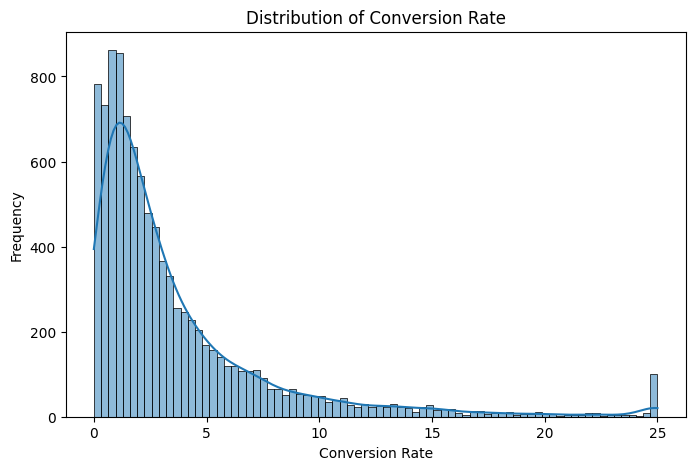

In [16]:
# Creating a figure with a specified size for better visualization clarity
plt.figure(figsize=(8, 5))
# Plotting the distribution of the target variable along with a kernel density estimate
sns.histplot(data[target], kde=True)
# Adding a descriptive title to the plot
plt.title("Distribution of Conversion Rate")
# Labeling the x-axis to indicate the target variable
plt.xlabel("Conversion Rate")
# Labeling the y-axis to represent the frequency of observations
plt.ylabel("Frequency")
# Displaying the final visualization
plt.show()

###  Correlation with conversion rate

In [17]:
# Selecting only numerical columns from the dataset for correlation analysis
numeric_data = data_model.select_dtypes(include=["int64", "float64"])

# Computing the correlation of all numerical features with the target variable
correlation_with_target = numeric_data.corr()[target].sort_values(ascending=False)

# Displaying the correlation values in descending order
correlation_with_target

,conversion_rate
conversion_rate,1.000000
pages_per_session,0.445679
avg_session_duration_seconds,0.343707
CTR,0.316528
ad_spend,0.136325
CPC,0.106129
actual_cpc,0.106129
clicks,0.094693
quarter,0.089760
quality_score,0.080473


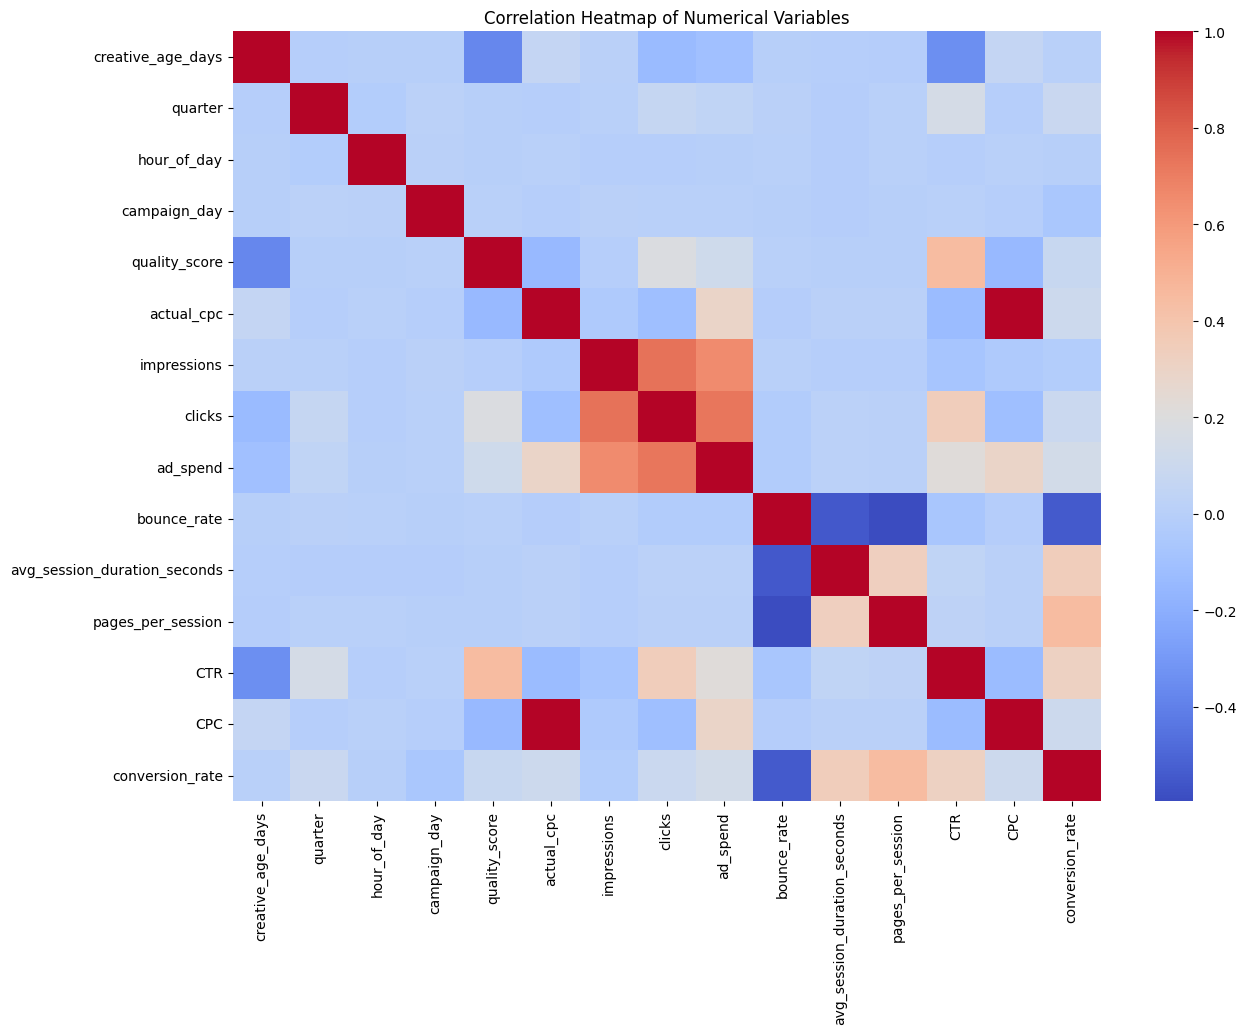

In [18]:
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Relationship Between Engagement Metrics and Conversion Rate

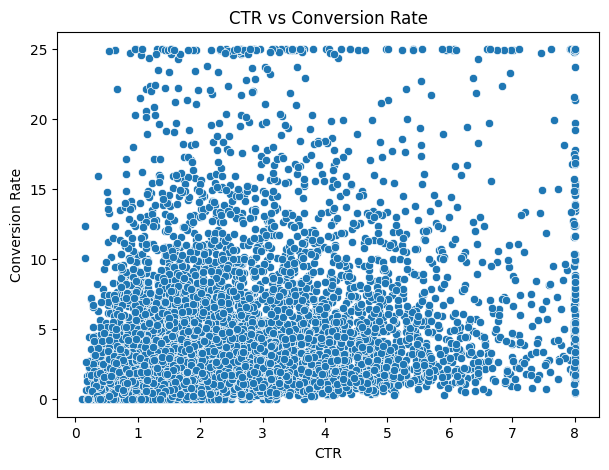

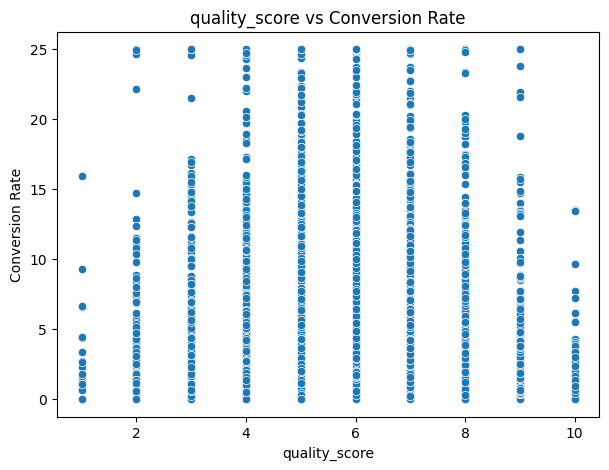

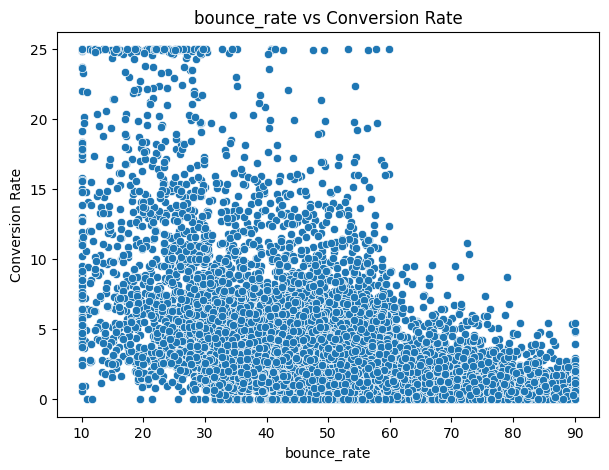

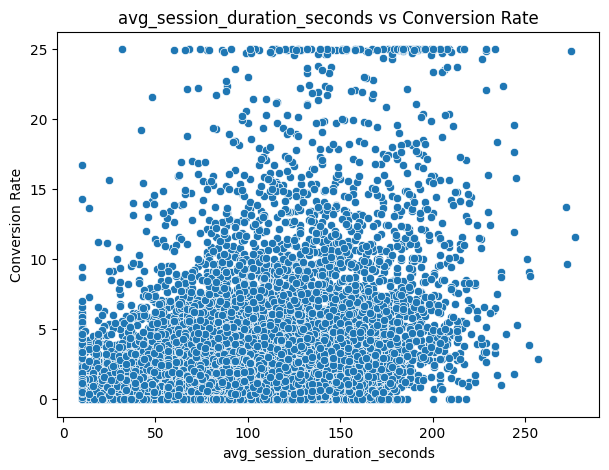

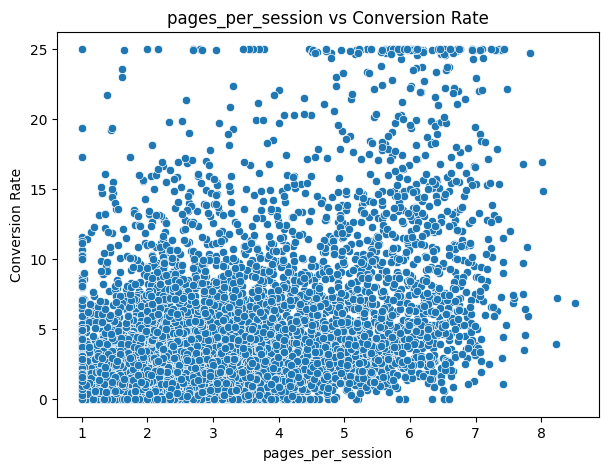

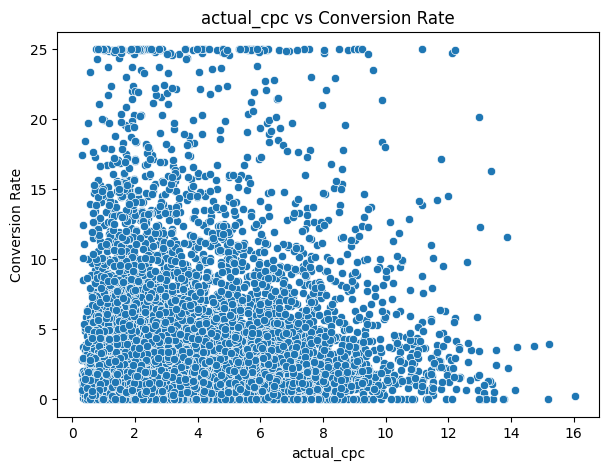

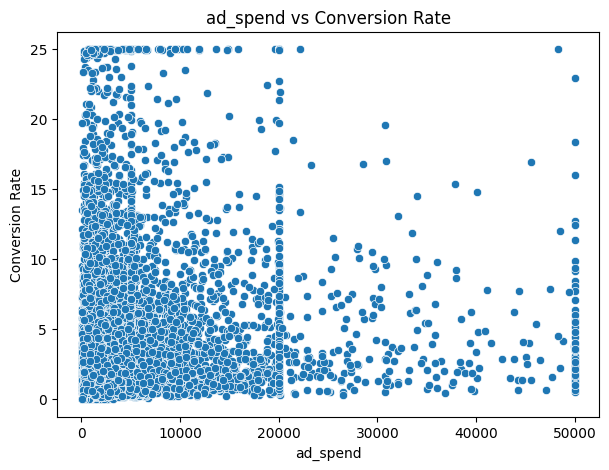

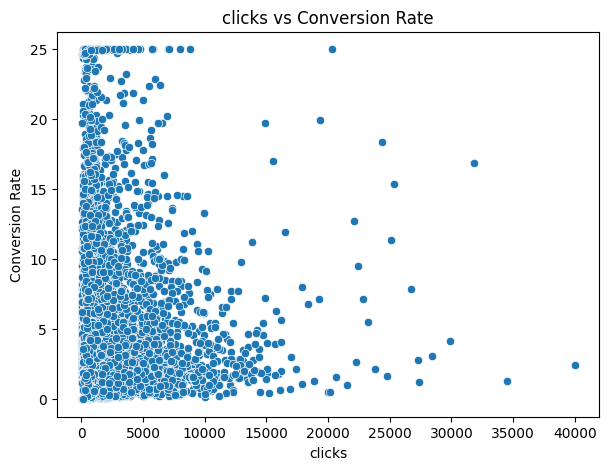

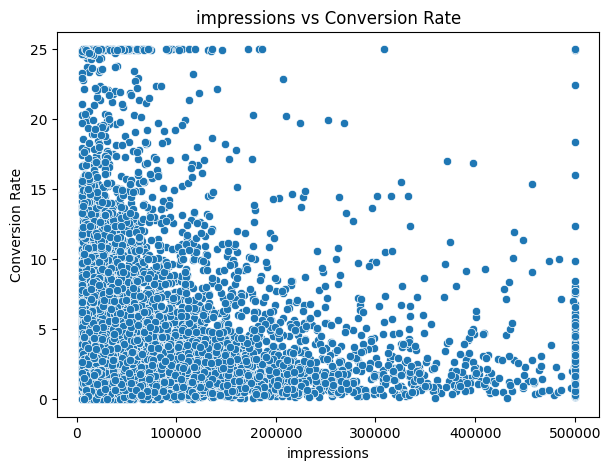

In [19]:
# Defining important numerical features for relationship analysis with the target variable
important_numeric_features = [
    "CTR",
    "quality_score",
    "bounce_rate",
    "avg_session_duration_seconds",
    "pages_per_session",
    "actual_cpc",
    "ad_spend",
    "clicks",
    "impressions"
]

# Creating scatter plots to examine the relationship between each feature and the target variable
for col in important_numeric_features:
    if col in data.columns:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x=data[col], y=data[target])

        # Adding descriptive plot title and axis labels
        plt.title(f"{col} vs Conversion Rate")
        plt.xlabel(col)
        plt.ylabel("Conversion Rate")

        # Displaying the scatter plot
        plt.show()

###  Platform-wise conversion rate

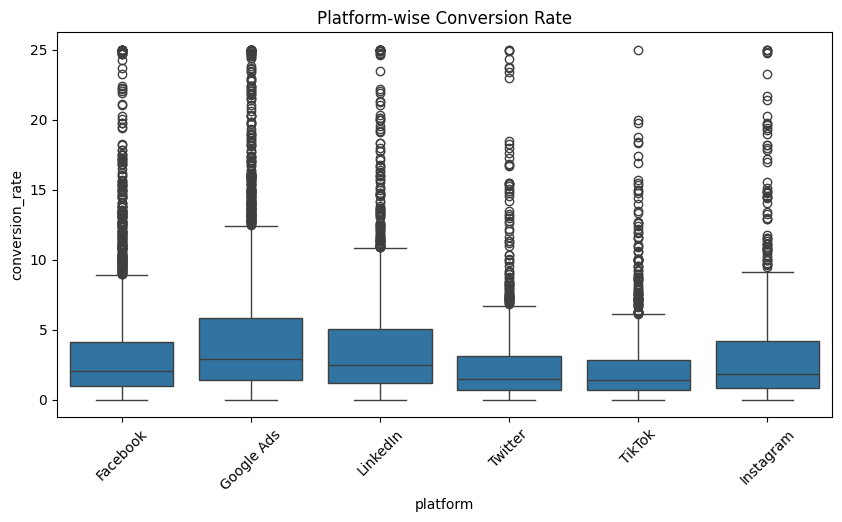

In [20]:

if "platform" in data.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="platform", y=target, data=data)
    plt.title("Platform-wise Conversion Rate")
    plt.xticks(rotation=45)
    plt.show()

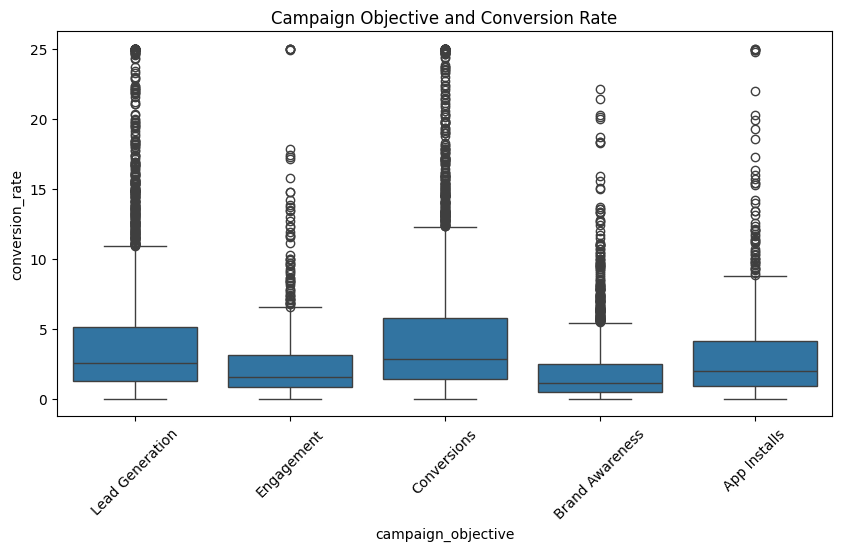

In [21]:
# Campaign objective and conversion rate

if "campaign_objective" in data.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="campaign_objective", y=target, data=data)
    plt.title("Campaign Objective and Conversion Rate")
    plt.xticks(rotation=45)
    plt.show()

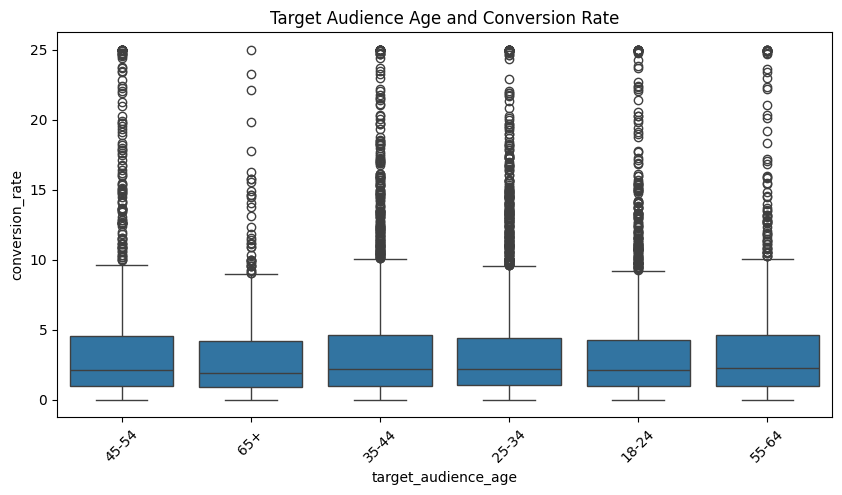

In [22]:
# Audience age and conversion rate

if "target_audience_age" in data.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="target_audience_age", y=target, data=data)
    plt.title("Target Audience Age and Conversion Rate")
    plt.xticks(rotation=45)
    plt.show()

In [23]:
# ============================================================
# Model Performance WITH Leakage Variables (Before Removal)
# This cell must run BEFORE leakage columns are dropped (In [14])
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define target
target = "conversion_rate"

# Use full data (still includes revenue, profit, ROAS)
X_leak = data.drop(columns=[target])
y_leak = data[target]

# Keep only numeric columns for simplicity
X_leak = X_leak.select_dtypes(include=[np.number])

# Train-test split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42
)

# Define models
rf_leak = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])
xgb_leak = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])

# Train
rf_leak.fit(X_train_l, y_train_l)
xgb_leak.fit(X_train_l, y_train_l)

# Predict
rf_leak_pred  = rf_leak.predict(X_test_l)
xgb_leak_pred = xgb_leak.predict(X_test_l)

# Evaluate
def leakage_eval(name, y_true, y_pred):
    return {
        "Model": name,
        "Dataset Version": "With leakage variables",
        "R2 Score": round(r2_score(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "MAE": round(mean_absolute_error(y_true, y_pred), 4)
    }

leakage_results = pd.DataFrame([
    leakage_eval("Random Forest",  y_test_l, rf_leak_pred),
    leakage_eval("XGBoost",        y_test_l, xgb_leak_pred),
])

print("=== Model Performance WITH Leakage Variables ===")
print(leakage_results.to_string(index=False))

=== Model Performance WITH Leakage Variables ===
        Model        Dataset Version  R2 Score   RMSE    MAE
Random Forest With leakage variables    0.9851 0.5065 0.1513
      XGBoost With leakage variables    0.9776 0.6222 0.3175


## Feature Engineering

Feature engineering is applied to create additional useful variables that may improve predictive performance.

The engineered features are based on advertising logic and user engagement behaviour.

In [24]:
# Creating new interaction-based features to improve predictive performance

data_model ["engagement_score" ] = (data_model ["CTR" ] * data_model ["pages_per_session" ] )
data_model ["spend_per_click" ] = data_model ["ad_spend" ] / (data_model ["clicks" ] + 1 )
data_model ["click_efficiency" ] = data_model ["clicks" ] / (data_model ["impressions" ] + 1 )

# Displaying the first few rows of the updated dataset
data_model.head()

,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,...,budget_tier,CTR,CPC,conversion_rate,start_month,start_day,start_dayofweek,engagement_score,spend_per_click,click_efficiency
0,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,...,High,0.606,2.23,0.498,3,6,2,1.21200,2.224467,0.006061
1,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,...,Medium,0.932,2.48,1.071,1,26,4,2.55368,2.474701,0.009322
2,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,...,Low,1.033,3.88,5.357,5,15,3,4.10101,3.845664,0.010329
3,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,...,Medium,1.573,8.29,2.439,7,21,6,3.91677,8.223145,0.015727
4,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,...,Low,1.409,1.41,0.000,3,9,6,4.28336,1.405347,0.014088


In [25]:
# Redefine X and y after feature engineering

X = data_model.drop(columns=[target])
y = data_model[target]

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

In [26]:
# Splitting the dataset into training and testing sets for model evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Displaying the shape of training and testing feature sets

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (8000, 39)
Testing feature shape: (2000, 39)


## Preprocessing Pipeline

Categorical variables are encoded using One-Hot Encoding. Numerical variables are scaled using StandardScaler. Missing values are handled using median imputation for numerical variables and most frequent imputation for categorical variables.

Using a pipeline ensures that preprocessing is applied consistently to both training and testing data.

In [27]:
# Identify categorical and numerical columns

categorical_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['campaign_objective', 'platform', 'ad_placement', 'device_type', 'operating_system', 'creative_format', 'creative_size', 'ad_copy_length', 'has_call_to_action', 'creative_emotion', 'target_audience_age', 'target_audience_gender', 'audience_interest_category', 'income_bracket', 'purchase_intent_score', 'retargeting_flag', 'day_of_week', 'industry_vertical', 'budget_tier']
Numerical columns: ['creative_age_days', 'quarter', 'hour_of_day', 'campaign_day', 'quality_score', 'actual_cpc', 'impressions', 'clicks', 'ad_spend', 'bounce_rate', 'avg_session_duration_seconds', 'pages_per_session', 'CTR', 'CPC', 'engagement_score', 'spend_per_click', 'click_efficiency']


In [28]:
# Creating a preprocessing pipeline for numerical features

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Creating a preprocessing pipeline for categorical features

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining numerical and categorical preprocessing steps into a single transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

## Model Development

Three machine learning regression models are developed and compared:

1. Linear Regression  
2. Random Forest Regression  
3. XGBoost Regression  

This section directly supports the third objective:

**To construct and contrast machine learning models to predict conversion rates.**

In [29]:
# Defining a pipeline for Linear Regression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Defining a pipeline for Random Forest Regression

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# Defining a pipeline for XGBoost Regression

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    ))
])

In [30]:
# Train Linear Regression
linear_model.fit(X_train, y_train)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Train XGBoost
xgb_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## Model Evaluation

The models are evaluated using the following statistical measures:

- Mean Absolute Error  
- Mean Squared Error  
- Root Mean Squared Error  
- R-squared Score  

This section directly supports the fourth objective:

**To measure the performance of these models with relevant statistical measures.**

In [31]:
# Prediction

linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [32]:
# Defining a function to evaluate regression model performance using common metrics

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Returning evaluation results as a dictionary
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [33]:
# Compare model performance

results = []

results.append(evaluate_model("Linear Regression", y_test, linear_pred))
results.append(evaluate_model("Random Forest Regression", y_test, rf_pred))
results.append(evaluate_model("XGBoost Regression", y_test, xgb_pred))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.767302,6.503698,2.550235,0.622855
1,Random Forest Regression,1.418994,5.409210,2.325771,0.686323
2,XGBoost Regression,1.096354,3.426458,1.851069,0.801302


In [34]:
# Sort models by R2 score
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,XGBoost Regression,1.096354,3.426458,1.851069,0.801302
1,Random Forest Regression,1.418994,5.409210,2.325771,0.686323
0,Linear Regression,1.767302,6.503698,2.550235,0.622855


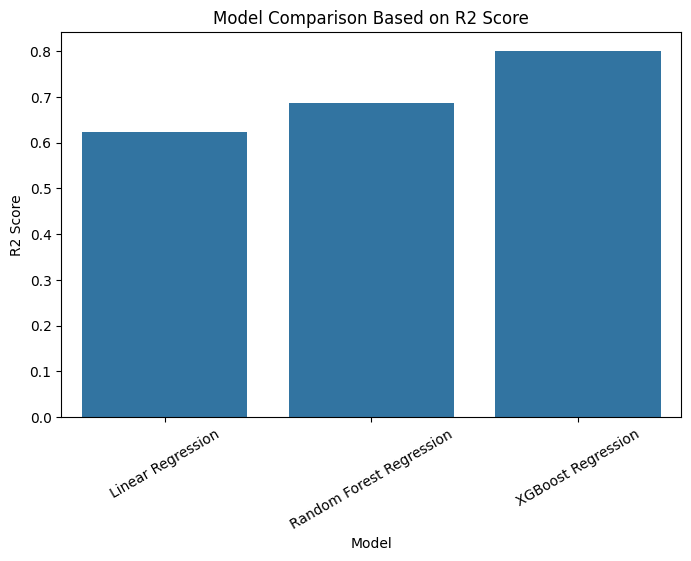

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.title("Model Comparison Based on R2 Score")
plt.xticks(rotation=30)
plt.show()

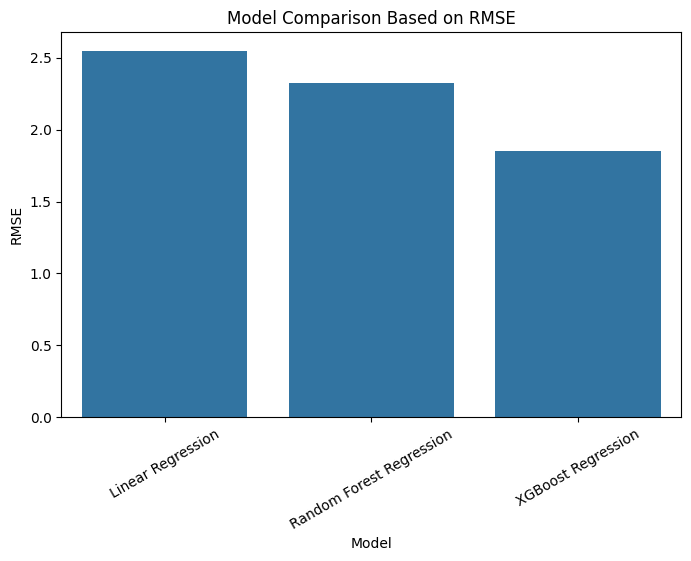

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=30)
plt.show()

## Cross-Validation

Cross-validation is used to assess the stability and generalisability of model performance. This helps ensure that the results are not dependent on only one train-test split.

In [37]:
# Creating a dictionary containing all regression models for cross-validation
models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Initializing a list to store cross-validation results
cv_results = []

# Performing 5-fold cross-validation for each model
for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    # Storing the mean and standard deviation of R² scores
    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

# Converting cross-validation results into a DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Displaying the cross-validation performance of all models
cv_results_df

,Model,Mean CV R2,Std CV R2
0,Linear Regression,0.631132,0.005422
1,Random Forest,0.698439,0.014971
2,XGBoost,0.820816,0.005037


## Feature Importance Analysis

Feature importance is used to identify the most influential factors affecting conversion rate. This section directly supports the second objective:


In [38]:
# Get feature names after preprocessing

preprocessor_fitted = rf_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_names[:10]

array(['num__creative_age_days', 'num__quarter', 'num__hour_of_day',
       'num__campaign_day', 'num__quality_score', 'num__actual_cpc',
       'num__impressions', 'num__clicks', 'num__ad_spend',
       'num__bounce_rate'], dtype=object)

In [39]:
# Extracting feature importance scores from the trained Random Forest model
rf_importance = rf_model.named_steps["model"].feature_importances_

# Creating a DataFrame to organize feature names and their importance values
rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

# Displaying the top 20 most important features
rf_feature_importance.head(20)

,Feature,Importance
9,num__bounce_rate,0.355906
14,num__engagement_score,0.081419
34,cat__device_type_Desktop,0.069952
18,cat__campaign_objective_Brand Awareness,0.044805
10,num__avg_session_duration_seconds,0.030539
3,num__campaign_day,0.026770
88,cat__retargeting_flag_True,0.023926
0,num__creative_age_days,0.022758
16,num__click_efficiency,0.022077
12,num__CTR,0.021466


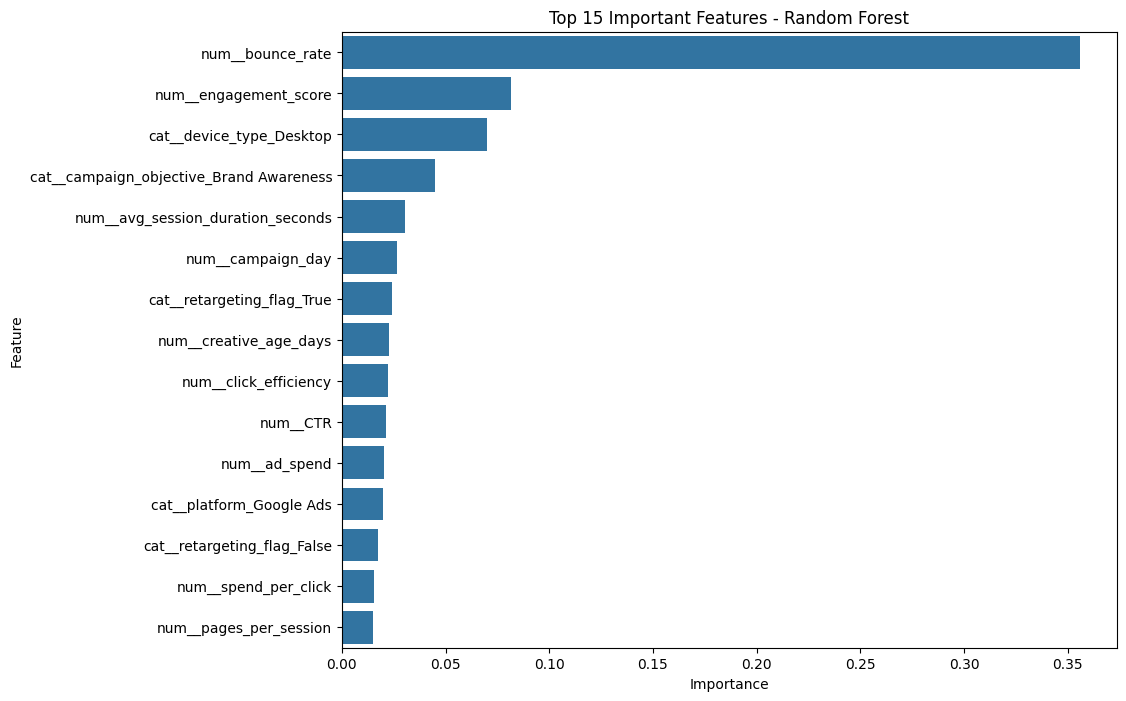

In [40]:
# Creating a bar plot to visualize the most important features from the Random Forest model
plt.figure(figsize=(10, 8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_feature_importance.head(15)
)

# Adding a descriptive title to the visualization
plt.title("Top 15 Important Features - Random Forest")

# Displaying the feature importance plot
plt.show()

In [41]:
# XGBoost feature importance

xgb_importance = xgb_model.named_steps["model"].feature_importances_

xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
}).sort_values(by="Importance", ascending=False)

xgb_feature_importance.head(20)

,Feature,Importance
9,num__bounce_rate,0.089926
84,cat__purchase_intent_score_High,0.077732
34,cat__device_type_Desktop,0.054242
18,cat__campaign_objective_Brand Awareness,0.053739
87,cat__retargeting_flag_False,0.040550
96,cat__industry_vertical_E-commerce,0.035912
23,cat__platform_Google Ads,0.031659
19,cat__campaign_objective_Conversions,0.031393
14,num__engagement_score,0.028823
21,cat__campaign_objective_Lead Generation,0.027632


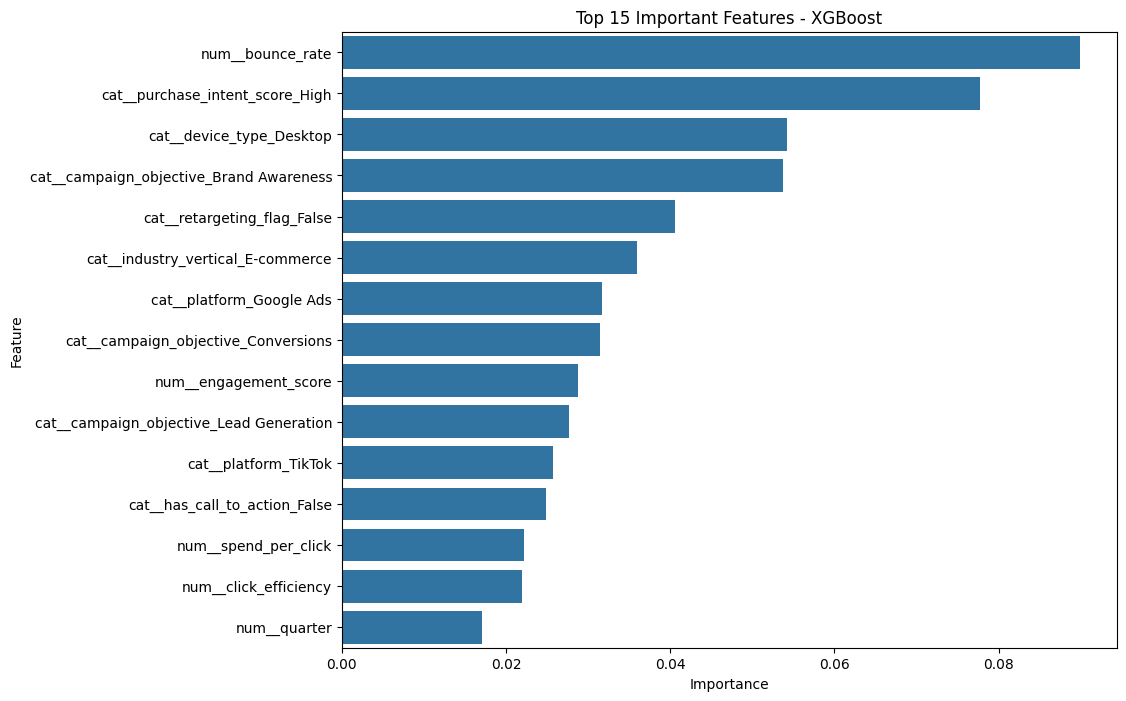

In [42]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_feature_importance.head(15)
)
plt.title("Top 15 Important Features - XGBoost")
plt.show()

## Actual vs Predicted Values

The actual versus predicted plot is used to visually assess how close the predicted conversion rates are to the real conversion rates. A model with strong predictive performance should produce points close to the diagonal pattern.

In [43]:
# Identifying the model with the highest R² score
best_model_name = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]["Model"]

# Selecting predictions corresponding to the best-performing model
if best_model_name == "Linear Regression":
    best_pred = linear_pred
elif best_model_name == "Random Forest Regression":
    best_pred = rf_pred
else:
    best_pred = xgb_pred

# Displaying the name of the best-performing model
print("Best Model:", best_model_name)

Best Model: XGBoost Regression


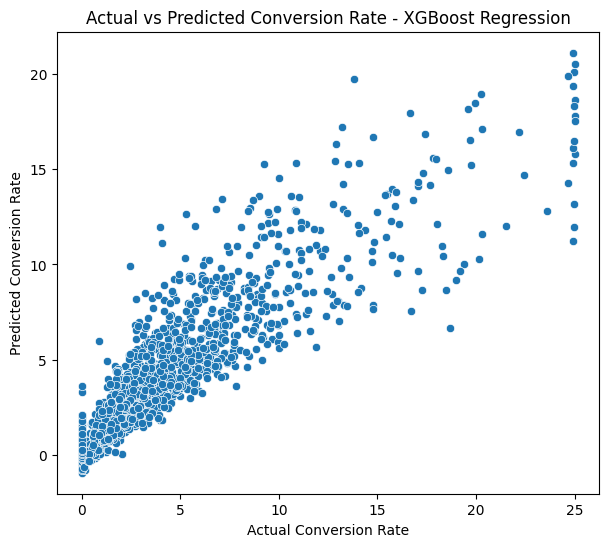

In [44]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel("Actual Conversion Rate")
plt.ylabel("Predicted Conversion Rate")
plt.title(f"Actual vs Predicted Conversion Rate - {best_model_name}")
plt.show()

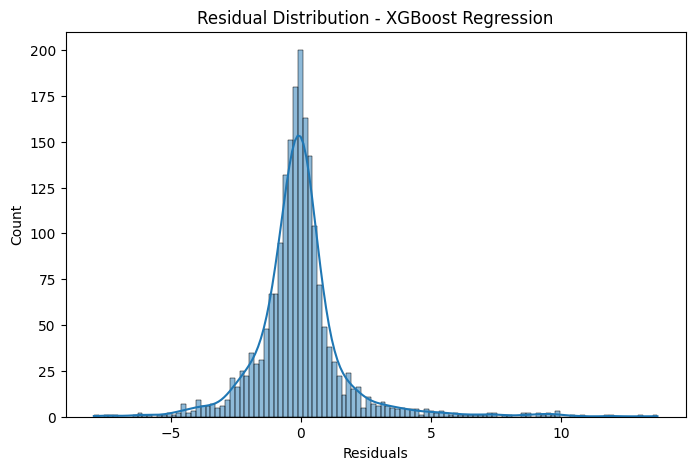

In [45]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residuals")
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the Random Forest model. This step demonstrates a more advanced and systematic model optimisation process.

In [46]:
# Defining the parameter grid for Random Forest hyperparameter optimization
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

# Initializing GridSearchCV to identify the optimal model configuration
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Fitting the grid search model on the training dataset
grid_search.fit(X_train, y_train)

# Displaying the best hyperparameters and corresponding cross-validation R² score
print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R2: 0.6754895031780249


In [47]:
# Extracting the best-performing Random Forest model from grid search
tuned_rf_model = grid_search.best_estimator_

# Generating predictions on the test dataset using the tuned model
tuned_rf_pred = tuned_rf_model.predict(X_test)

# Evaluating the tuned Random Forest model using regression metrics
tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred
)

# Converting the evaluation results into a DataFrame for display
pd.DataFrame([tuned_rf_results])

,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Random Forest,1.422114,5.433581,2.331004,0.68491
